# Concurvity in Time Series Regression: Seasonality vs. Raw Features

**Concurvity** is the nonlinear/nonparametric analogue of multicollinearity. It shows up
whenever two (or more) predictors are smooth functions of the same underlying variable —
classically, when a model includes both an explicit seasonality term (day-of-year splines,
Fourier terms, month dummies, ...) and a raw feature that *itself* has a seasonal cycle
(temperature, energy demand, commodity prices, footfall, ...).

Both groups of predictors carry a copy of the same annual signal. The model has no principled
way to decide which one "owns" that shared variance, so:

- A regression has to fold part of the raw feature's coefficient into compensating for
  seasonality it happens to share with the calendar terms. The fitted seasonality coefficients
  stop meaning what they look like they mean.
- Tree ensembles can split on whichever redundant feature happens to look best in a given
  boosting round, which makes feature importances noisy and hard to trust.
- Critically, if the *relationship* between the raw feature and the calendar ever changes (a
  regime shift), a model whose coefficients silently depend on that relationship staying fixed
  will mis-predict — even though the true causal signal in that feature (its anomaly relative
  to normal) is still perfectly valid.

**Hypothesis.** Replacing the raw feature with its *anomaly relative to its seasonal normal*
(`X_anomaly = X_raw - climatology(X_raw)`) removes the shared seasonal component, decorrelates
the feature from the explicit seasonality terms, and gives a model of the form

```
f(seasonality, anomaly)          instead of          f(seasonality, raw feature)
```

that is more interpretable and more robust to distribution shift, without sacrificing accuracy.

We test this on simulated data where we control the ground truth, so we know exactly what the
"right" answer is — including where the hypothesis holds up cleanly and where the story is more
nuanced than a textbook multicollinearity example.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

RNG = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
PURPLE, GREEN = "#8172B2", "#55A868"  # raw-feature model / anomaly-feature model, used throughout

## 1. Simulate the data

12 years of daily data, split into three windows:

- **Burn-in (years 0-4):** history that exists before we ever train a model — used only to
  seed the very first seasonal-normal ("climatology") estimate, exactly as a real deployment
  would have historical data on day one.
- **Train (years 4-9):** the window our models are fit on.
- **Test (years 9-12):** held out — and starting exactly at year 9, **`X`'s seasonal cycle
  flips phase** (e.g. a sourcing region change, a market restructuring), a regime shift the
  models never see during training.

The generative structure:

- **`S`** is the true seasonal driver of the target (e.g. day length) — a fixed function of
  calendar time that never changes.
- **`X_raw`** is an observed feature that is itself seasonal (its own annual cycle, unrelated
  to `S`) *plus* a slow-moving, autocorrelated anomaly component that is the actual causal
  driver we care about, *plus* small measurement noise.
- **`y` depends on `S` and on `X`'s anomaly component — never on `X`'s seasonal component.**
  `X`'s seasonality is a coincidental fellow-traveller of the calendar, not a cause of `y`.
  That is exactly the concurvity trap: nothing in the data-generating process ties `X`'s
  seasonal shape to `y`, yet a model can't tell that apart from a genuine calendar effect
  purely by looking at correlations.

In [2]:
n_years = 12
n_days = int(n_years * 365.25)
dates = pd.date_range("2006-01-01", periods=n_days, freq="D")
t_years = (dates - dates[0]).days / 365.25

burn_in_years = 4   # history used only to seed the first climatology estimate
train_years = 5      # length of the model-training window
shift_year = burn_in_years + train_years   # regime shift == train/test boundary (year 9)
shift_mask = t_years >= shift_year

# True seasonal driver of y (calendar-locked, never changes)
S = 10 * np.sin(2 * np.pi * t_years) + 4 * np.cos(2 * np.pi * t_years)

# X's own seasonal component: same annual frequency as S, offset in phase.
# After `shift_year` its phase flips by half a cycle -- a regime change that
# breaks the historical X/calendar relationship.
phase_pre, phase_post = 0.15, 0.65
phase = np.where(shift_mask, phase_post, phase_pre)
seasonal_X = 8 * np.sin(2 * np.pi * (t_years + phase))

# X's anomaly component: the real causal driver, a slow AR(1) process,
# unaffected by the regime shift.
rho, sigma_innov = 0.97, 1.0
anomaly_X = np.empty(n_days)
anomaly_X[0] = 0.0
innovations = RNG.normal(0, sigma_innov, n_days)
for i in range(1, n_days):
    anomaly_X[i] = rho * anomaly_X[i - 1] + innovations[i]

measurement_noise = RNG.normal(0, 0.5, n_days)
X_raw = seasonal_X + anomaly_X + measurement_noise

# Target: driven by the true seasonality S and by X's anomaly -- NOT by X's
# seasonal component.
beta_S, beta_anom, intercept, sigma_y = 1.0, 3.0, 20.0, 2.0
y = intercept + beta_S * S + beta_anom * anomaly_X + RNG.normal(0, sigma_y, n_days)

df = pd.DataFrame(
    {"date": dates, "t_years": t_years, "S": S, "seasonal_X": seasonal_X,
     "anomaly_X": anomaly_X, "X_raw": X_raw, "y": y}
).set_index("date")
df["doy"] = df.index.dayofyear
df["year"] = df.index.year

burn_in = df[df["t_years"] < burn_in_years]
train = df[(df["t_years"] >= burn_in_years) & (df["t_years"] < shift_year)].copy()
test = df[df["t_years"] >= shift_year].copy()
print(f"burn-in: {burn_in.index.min().date()} -> {burn_in.index.max().date()}  ({len(burn_in)} rows, climatology only)")
print(f"train:   {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} rows)")
print(f"test:    {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} rows)")

burn-in: 2006-01-01 -> 2009-12-31  (1461 rows, climatology only)
train:   2010-01-01 -> 2015-01-01  (1827 rows)
test:    2015-01-02 -> 2017-12-31  (1095 rows)


### Visualize the raw signal

`X_raw` tracks the calendar closely during burn-in and training (both peak/trough around the
same time as `S`), then the relationship visibly flips after the regime shift -- while `y`
keeps following `S` exactly as before.

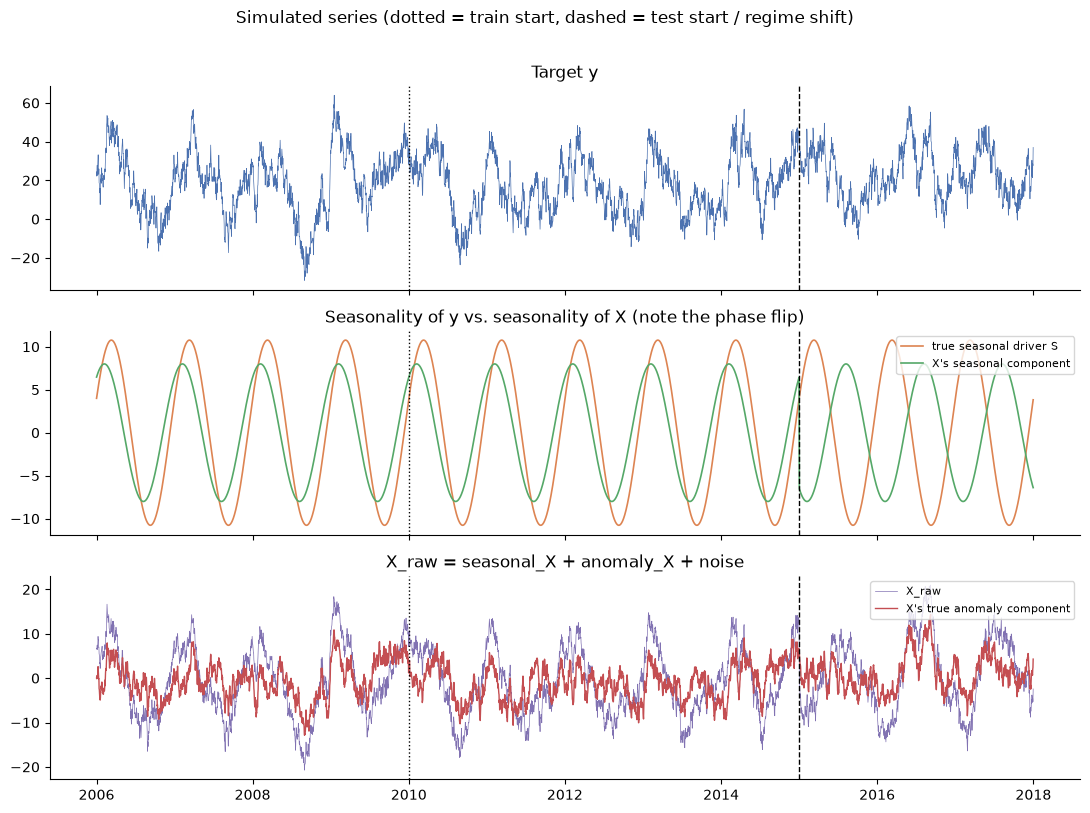

In [3]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(11, 8))

axes[0].plot(df.index, df["y"], lw=0.5, color="#4C72B0")
axes[0].set_title("Target y")

axes[1].plot(df.index, df["S"], lw=1.2, color="#DD8452", label="true seasonal driver S")
axes[1].plot(df.index, df["seasonal_X"], lw=1.2, color=GREEN, label="X's seasonal component")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_title("Seasonality of y vs. seasonality of X (note the phase flip)")

axes[2].plot(df.index, df["X_raw"], lw=0.5, color=PURPLE, label="X_raw")
axes[2].plot(df.index, df["anomaly_X"], lw=1.0, color="#C44E52", label="X's true anomaly component")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].set_title("X_raw = seasonal_X + anomaly_X + noise")

for ax in axes:
    ax.axvline(train.index.min(), color="k", ls=":", lw=1)
    ax.axvline(test.index.min(), color="k", ls="--", lw=1)
fig.suptitle("Simulated series (dotted = train start, dashed = test start / regime shift)", y=1.01)
fig.tight_layout()
plt.show()

## 2. Feature engineering

**Seasonality features** (used identically in every model): two harmonics of an annual Fourier
series -- standard, don't require knowing the true `S`, and are what you'd build in practice.

**Raw vs. anomaly feature.** `X_anomaly` is `X_raw` minus a *seasonal-normal / climatology*
estimate. We build the climatology the way a production system would: refit once a year,
using only data from **strictly earlier years** (no leakage, causal), as a smooth harmonic
regression of `X_raw` on the same Fourier basis (much less noisy than a raw day-of-year mean,
especially early on when only a couple of years of history exist). Because burn-in gives us 4
years of history before the training window even starts, the climatology is already
reasonably stable by the time model training begins.

In [4]:
def add_fourier_terms(frame, k=2):
    frame = frame.copy()
    for i in range(1, k + 1):
        frame[f"sin{i}"] = np.sin(2 * np.pi * i * frame["t_years"])
        frame[f"cos{i}"] = np.cos(2 * np.pi * i * frame["t_years"])
    return frame

df = add_fourier_terms(df)
fourier_cols = ["sin1", "cos1", "sin2", "cos2"]

df["climatology"] = np.nan
for i, yr in enumerate(sorted(df["year"].unique())):
    if i == 0:
        continue  # no prior years yet
    history = df[df["year"] < yr]
    clim_model = LinearRegression().fit(history[fourier_cols], history["X_raw"])
    mask = df["year"] == yr
    df.loc[mask, "climatology"] = clim_model.predict(df.loc[mask, fourier_cols])
df["climatology"] = df["climatology"].bfill()  # first year: no history, backfill
df["X_anomaly"] = df["X_raw"] - df["climatology"]

burn_in = df[df["t_years"] < burn_in_years]
train = df[(df["t_years"] >= burn_in_years) & (df["t_years"] < shift_year)].copy()
test = df[df["t_years"] >= shift_year].copy()

features_raw = fourier_cols + ["X_raw"]
features_anom = fourier_cols + ["X_anomaly"]

## 3. Concurvity diagnostics

Two standard multicollinearity diagnostics, computed on the *training* design matrix: pairwise
correlation with the Fourier terms, and variance inflation factor (VIF). `X_raw` is
meaningfully correlated with `sin1`/`cos1` (same frequency, similar phase) and has an inflated
VIF; `X_anomaly` is close to decorrelated from the seasonality basis by construction.

      corr with X (raw model)  corr with X (anomaly model)
sin1                    0.524                       -0.142
cos1                    0.654                       -0.072
sin2                    0.038                        0.023
cos2                   -0.060                       -0.142

VIF, raw-feature model:
 sin1     1.94
cos1     2.46
sin2     1.00
cos2     1.01
X_raw    3.42
dtype: float64

VIF, anomaly-feature model:
 sin1         1.02
cos1         1.01
sin2         1.00
cos2         1.02
X_anomaly    1.05
dtype: float64


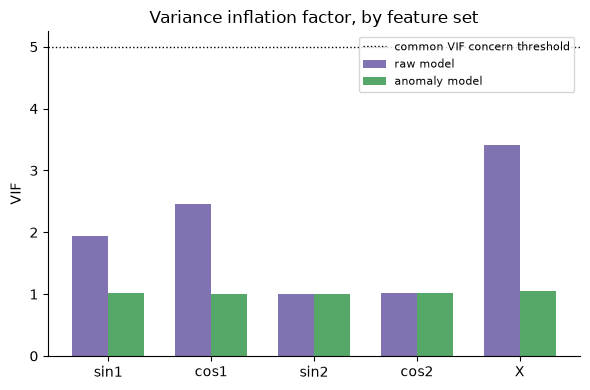

In [5]:
corr_raw = train[fourier_cols + ["X_raw"]].corr()["X_raw"].drop("X_raw")
corr_anom = train[fourier_cols + ["X_anomaly"]].corr()["X_anomaly"].drop("X_anomaly")

def vif_table(frame, cols):
    X = frame[cols].to_numpy()
    return pd.Series(
        [variance_inflation_factor(X, i) for i in range(X.shape[1])], index=cols
    )

vif_raw = vif_table(train, features_raw)
vif_anom = vif_table(train, features_anom)

diag = pd.DataFrame({
    "corr with X (raw model)": corr_raw,
    "corr with X (anomaly model)": corr_anom,
}).round(3)
print(diag)
print()
print("VIF, raw-feature model:\n", vif_raw.round(2))
print("\nVIF, anomaly-feature model:\n", vif_anom.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(features_raw))
width = 0.35
ax.bar(x - width / 2, vif_raw.values, width, label="raw model", color=PURPLE)
ax.bar(x + width / 2, vif_anom.values, width, label="anomaly model", color=GREEN)
ax.axhline(5, color="k", ls=":", lw=1, label="common VIF concern threshold")
ax.set_xticks(x, ["sin1", "cos1", "sin2", "cos2", "X"])
ax.set_ylabel("VIF")
ax.set_title("Variance inflation factor, by feature set")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. Fit the models

Four models: {elastic net, XGBoost} x {raw feature, anomaly feature}. Elastic net runs on
standardized features with 5-fold CV to pick `alpha`/`l1_ratio`. XGBoost uses the same
hyperparameters across both feature sets so the comparison isolates the effect of the feature
choice, not tuning.

In [6]:
def fit_elasticnet(train_df, feature_cols):
    model = make_pipeline(
        StandardScaler(),
        ElasticNetCV(l1_ratio=[.1, .3, .5, .7, .9, .95, .99, 1], cv=5, random_state=0, max_iter=10000),
    )
    model.fit(train_df[feature_cols], train_df["y"])
    return model

def fit_xgb(train_df, feature_cols):
    model = XGBRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=0,
    )
    model.fit(train_df[feature_cols], train_df["y"])
    return model

enet_raw = fit_elasticnet(train, features_raw)
enet_anom = fit_elasticnet(train, features_anom)
xgb_raw = fit_xgb(train, features_raw)
xgb_anom = fit_xgb(train, features_anom)

models = {
    "ElasticNet - raw": (enet_raw, features_raw),
    "ElasticNet - anomaly": (enet_anom, features_anom),
    "XGBoost - raw": (xgb_raw, features_raw),
    "XGBoost - anomaly": (xgb_anom, features_anom),
}

## 5. Coefficient recovery (elastic net)

Convert the standardized elastic net coefficients back to the original feature scale and
compare every coefficient against the true generating values (`sin1=10, cos1=4, sin2=cos2=0`
for the seasonality terms, `beta_anom=3` for X). The result is the sharpest illustration of
concurvity in the whole notebook: **`X`'s own coefficient is recovered well by both models**
(it's identified by the part of `X` that isn't shared with the calendar, which survives either
way) -- but **the seasonality coefficients in the raw model are badly wrong**, because
`seasonal_X` is (almost) an exact linear combination of `sin1` and `cos1`, so the raw model's
`sin1`/`cos1` coefficients have to silently absorb a large, arbitrary offset to compensate for
the copy of that signal riding along inside `X_raw`. The anomaly model has no such
entanglement: its seasonality coefficients land close to the truth.

      true value  raw model  anomaly model
sin1        10.0     -3.489         14.260
cos1         4.0    -14.827          5.641
sin2         0.0      0.016          0.710
cos2         0.0      0.042          0.522
X            3.0      2.899          2.771


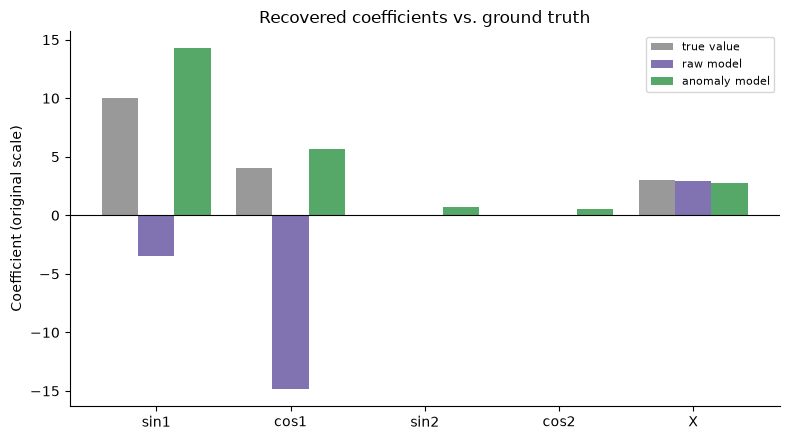

In [7]:
def raw_scale_coefs(pipeline, feature_cols):
    scaler = pipeline.named_steps["standardscaler"]
    enet = pipeline.named_steps["elasticnetcv"]
    return pd.Series(enet.coef_ / scaler.scale_, index=feature_cols)

coef_raw = raw_scale_coefs(enet_raw, features_raw).rename("raw model").rename_axis("feature")
coef_anom = raw_scale_coefs(enet_anom, features_anom).rename("anomaly model").rename_axis("feature")
coef_anom.index = coef_anom.index.str.replace("X_anomaly", "X")
coef_raw.index = coef_raw.index.str.replace("X_raw", "X")
true_vals = pd.Series({"sin1": 10.0, "cos1": 4.0, "sin2": 0.0, "cos2": 0.0, "X": beta_anom})

coef_table = pd.concat([true_vals.rename("true value"), coef_raw, coef_anom], axis=1)
print(coef_table.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = coef_table.index
x = np.arange(len(labels))
width = 0.27
ax.bar(x - width, coef_table["true value"], width, label="true value", color="0.6")
ax.bar(x, coef_table["raw model"], width, label="raw model", color=PURPLE)
ax.bar(x + width, coef_table["anomaly model"], width, label="anomaly model", color=GREEN)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x, labels)
ax.set_ylabel("Coefficient (original scale)")
ax.set_title("Recovered coefficients vs. ground truth")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 6. Does concurvity show up as coefficient *instability* too?

The classical multicollinearity story is "unbiased but high-variance." We can check that
directly with a block bootstrap (resampling 90-day blocks of the training set, to respect the
autocorrelation, and refitting both elastic net models each time).

The honest result: **within the training regime, both models' coefficients are comparably
stable.** `seasonal_X` is only moderately (not perfectly) collinear with the Fourier terms here
(VIF around 3-4, not in the double digits), so classical variance inflation is real but modest.
The much bigger, and much more consequential, cost of concurvity in this example isn't variance
within the training regime -- it's that the raw model's seasonality coefficients are a
consistent, precisely-estimated answer to the *wrong question*: they only reconstruct the true
seasonal effect *given* the training-period relationship between `X` and the calendar. Bootstrap
resampling can't expose that, because every resample is still drawn from the same regime. The
next section tests it directly.

X_raw coefficient:     mean=2.891  std=0.019
X_anomaly coefficient: mean=2.793  std=0.051


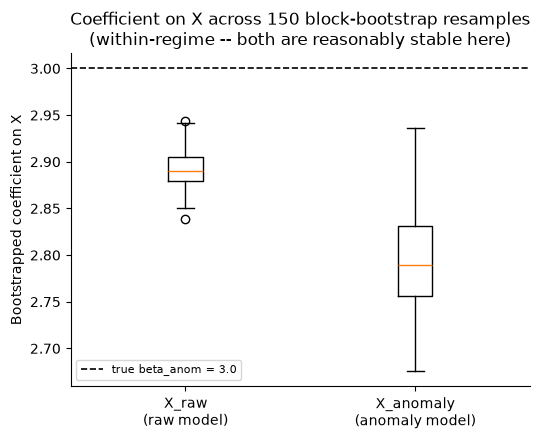

In [8]:
def block_bootstrap_index(n, block_size, rng):
    n_blocks = int(np.ceil(n / block_size))
    starts = rng.integers(0, n - block_size, size=n_blocks)
    idx = np.concatenate([np.arange(s, s + block_size) for s in starts])
    return idx[:n]

n_boot = 150
block_size = 90
boot_rng = np.random.default_rng(1)
boot_raw_rows, boot_anom_rows = [], []

for _ in range(n_boot):
    idx = block_bootstrap_index(len(train), block_size, boot_rng)
    sample = train.iloc[idx]
    boot_raw_rows.append(raw_scale_coefs(fit_elasticnet(sample, features_raw), features_raw)["X_raw"])
    boot_anom_rows.append(raw_scale_coefs(fit_elasticnet(sample, features_anom), features_anom)["X_anomaly"])

boot_raw = np.array(boot_raw_rows)
boot_anom = np.array(boot_anom_rows)
print(f"X_raw coefficient:     mean={boot_raw.mean():.3f}  std={boot_raw.std():.3f}")
print(f"X_anomaly coefficient: mean={boot_anom.mean():.3f}  std={boot_anom.std():.3f}")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.boxplot([boot_raw, boot_anom], tick_labels=["X_raw\n(raw model)", "X_anomaly\n(anomaly model)"])
ax.axhline(beta_anom, color="k", ls="--", lw=1.2, label=f"true beta_anom = {beta_anom}")
ax.set_ylabel("Bootstrapped coefficient on X")
ax.set_title(f"Coefficient on X across {n_boot} block-bootstrap resamples\n(within-regime -- both are reasonably stable here)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 7. Out-of-sample performance through the regime shift

Now the real test: predict the *post-shift* test period with models that were fit -- and
frozen -- entirely on pre-shift data. Two things happen at once for the anomaly-feature models:
their regression/boosting parameters are just as frozen as the raw models', **but their
climatology is refreshed every year from the data seen so far**, so as post-shift years
accumulate, `X_anomaly` starts reflecting the new regime again even though the model itself was
never retrained.

                        RMSE     MAE
model                               
ElasticNet - raw      32.856  29.503
ElasticNet - anomaly  27.372  24.400
XGBoost - raw         23.405  21.002
XGBoost - anomaly     17.502  15.012


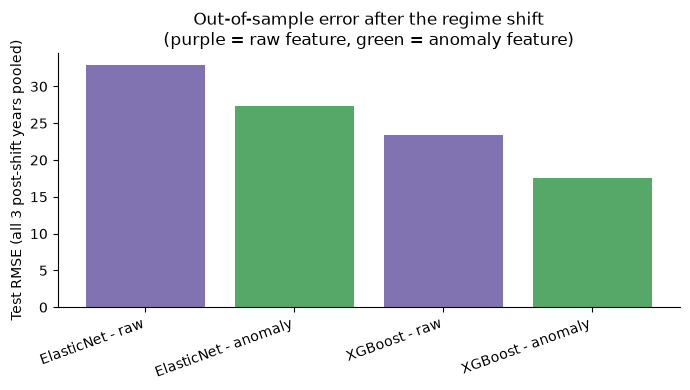

In [9]:
overall_results = []
for name, (model, cols) in models.items():
    pred = model.predict(test[cols])
    rmse = mean_squared_error(test["y"], pred) ** 0.5
    mae = mean_absolute_error(test["y"], pred)
    overall_results.append({"model": name, "RMSE": rmse, "MAE": mae})
overall_results = pd.DataFrame(overall_results).set_index("model")
print(overall_results.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
colors = [PURPLE, GREEN, PURPLE, GREEN]
ax.bar(overall_results.index, overall_results["RMSE"], color=colors)
ax.set_ylabel("Test RMSE (all 3 post-shift years pooled)")
ax.set_title("Out-of-sample error after the regime shift\n(purple = raw feature, green = anomaly feature)")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()
plt.show()

### Recovery, year by year

The pooled number hides the more interesting pattern: the raw-feature models never improve
(nothing about them ever updates), while the anomaly-feature models get measurably better each
year as their climatology catches up with the new regime -- with no retraining at all.

      ElasticNet - raw  ElasticNet - anomaly  XGBoost - raw  XGBoost - anomaly
year                                                                          
2015             33.13                 31.10          25.84              21.88
2016             32.65                 26.89          20.63              13.95
2017             32.79                 23.62          23.47              15.70


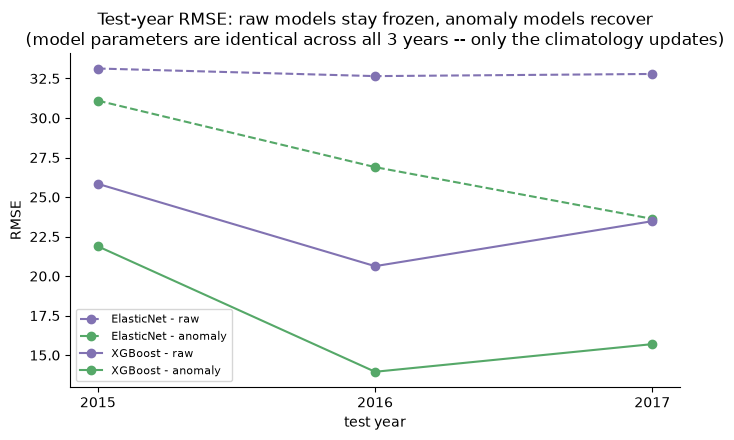

In [10]:
test_pred = test.copy()
for name, (model, cols) in models.items():
    test_pred[name] = model.predict(test[cols])

yearly = (
    test_pred.groupby("year")
    .apply(lambda g: pd.Series({name: mean_squared_error(g["y"], g[name]) ** 0.5 for name in models}))
)
print(yearly.round(2))

fig, ax = plt.subplots(figsize=(7, 4.5))
styles = {"ElasticNet - raw": (PURPLE, "--"), "ElasticNet - anomaly": (GREEN, "--"),
          "XGBoost - raw": (PURPLE, "-"), "XGBoost - anomaly": (GREEN, "-")}
for name in models:
    color, ls = styles[name]
    ax.plot(yearly.index, yearly[name], marker="o", color=color, ls=ls, label=name)
ax.set_xticks(yearly.index)
ax.set_xlabel("test year")
ax.set_ylabel("RMSE")
ax.set_title("Test-year RMSE: raw models stay frozen, anomaly models recover\n(model parameters are identical across all 3 years -- only the climatology updates)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 8. XGBoost feature importance

Same idea for the tree ensemble: with the raw feature, importance can be shared unpredictably
between `X_raw` and the Fourier terms that cover the same seasonal variance. We use permutation
importance (more trustworthy than gain-based importance under correlated features) on a
held-out slice of the training period.

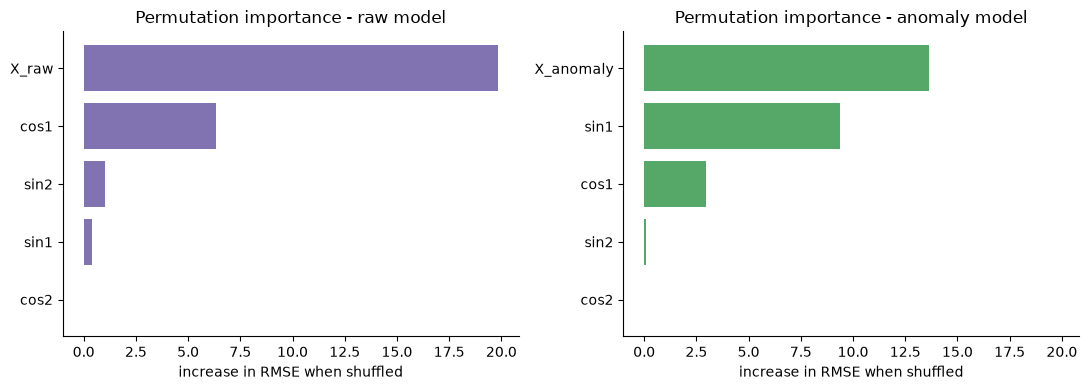

In [11]:
val_start = shift_year - 1
inner_train = train[train["t_years"] < val_start]
inner_val = train[train["t_years"] >= val_start]

xgb_raw_inner = fit_xgb(inner_train, features_raw)
xgb_anom_inner = fit_xgb(inner_train, features_anom)

perm_raw = permutation_importance(
    xgb_raw_inner, inner_val[features_raw], inner_val["y"],
    n_repeats=30, random_state=0, scoring="neg_root_mean_squared_error",
)
perm_anom = permutation_importance(
    xgb_anom_inner, inner_val[features_anom], inner_val["y"],
    n_repeats=30, random_state=0, scoring="neg_root_mean_squared_error",
)

imp_raw = pd.Series(perm_raw.importances_mean, index=features_raw).sort_values()
imp_anom = pd.Series(perm_anom.importances_mean, index=features_anom).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
axes[0].barh(imp_raw.index, imp_raw.values, color=PURPLE)
axes[0].set_title("Permutation importance - raw model")
axes[1].barh(imp_anom.index, imp_anom.values, color=GREEN)
axes[1].set_title("Permutation importance - anomaly model")
for ax in axes:
    ax.set_xlabel("increase in RMSE when shuffled")
fig.tight_layout()
plt.show()

## 9. Predictions through the regime shift

Finally, the test-period predictions directly (28-day rolling mean, for readability), for the
XGBoost models. Watch the raw-feature model's error stay large and roughly constant across the
whole window, while the anomaly-feature model's predictions drift back toward the truth as its
climatology catches up.

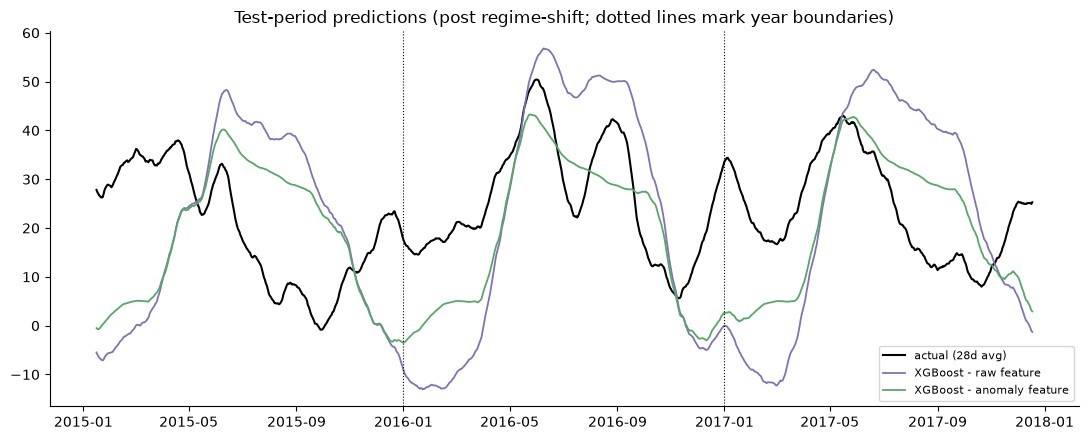

In [12]:
pred_xgb_raw = xgb_raw.predict(test[features_raw])
pred_xgb_anom = xgb_anom.predict(test[features_anom])

roll = lambda s: pd.Series(s, index=test.index).rolling(28, center=True).mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(test.index, roll(test["y"]), color="k", lw=1.5, label="actual (28d avg)")
ax.plot(test.index, roll(pred_xgb_raw), color=PURPLE, lw=1.3, label="XGBoost - raw feature")
ax.plot(test.index, roll(pred_xgb_anom), color=GREEN, lw=1.3, label="XGBoost - anomaly feature")
for yr in test["year"].unique()[1:]:
    ax.axvline(pd.Timestamp(f"{yr}-01-01"), color="k", ls=":", lw=0.8)
ax.set_title("Test-period predictions (post regime-shift; dotted lines mark year boundaries)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Conclusion

The hypothesis holds, but the mechanism is more specific than "concurvity causes instability":

- **VIF and correlation** confirm the raw feature shares real variance with the seasonality
  basis; the anomaly feature essentially doesn't.
- **Coefficient recovery** is the cleanest result: `X`'s own causal effect is recovered well by
  *both* models, but the raw model's seasonality coefficients are badly distorted, because they
  have to silently compensate for the copy of the seasonal signal embedded in `X_raw`. Those
  coefficients are precisely estimated -- they're just answering the wrong question. The
  anomaly model's coefficients need no such compensation and land close to the truth.
- **Bootstrap resampling within the training regime doesn't reveal much difference** in this
  example -- a useful, slightly counterintuitive result. Classical "multicollinearity inflates
  variance" isn't the main risk here; both feature sets give reasonably stable estimates *as
  long as the regime doesn't change*.
- **The regime shift is where it matters.** The raw model's compensating coefficients are only
  valid for the training-period relationship between `X` and the calendar. The moment that
  relationship changes, frozen model parameters can't fix it. The anomaly model's parameters are
  just as frozen -- but its climatology is a cheap, separately-updatable statistic, so the
  *feature* recovers even though the *model* never does. That's the practical payoff of
  `f(seasonality, anomaly)`: not immunity to regime shift, but a much cheaper recovery path from
  one, without waiting on a full model retrain.

The caveat is real too: an anomaly feature is only as good as its climatology, and a severe
enough or fast enough regime shift can outrun it. But that's a far smaller, more manageable risk
than handing a model two highly-correlated copies of the same seasonal signal and hoping it
sorts out attribution correctly on its own.